In [1]:
import os
from itertools import combinations
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, gaussian_kde
import pickle
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import cmasher as cmr
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc11 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(os.path.join('c:\\',*os.getcwd().split('\\')[1:-1], v1_xs_file))
#v1_scores = pd.read_pickle(os.path.join('/',*os.getcwd().split('/')[:-1], v1_xs_file))
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)

In [5]:
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [6]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [7]:
import joblib
P = joblib.load(
    os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'best_permutation.pkl')
)
optimized_model_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'permutation_test_free.pkl')
with open(optimized_model_file, 'rb') as f:
    optimized_model = pickle.load(f)

In [8]:
best = np.argsort(optimized_model['loss_decay'][-1])[0]

In [9]:
model = SGCCircuit(param_bounds, identify=False)

In [10]:
model.load_saved_parameters(optimized_model['final_epoch_params'])

In [11]:
predictions = model.predict(X)

In [12]:
v1_neuron_1, v1_neuron_2 = predictions[best]

In [13]:
low_sf_1 = v1_neuron_1[0]
high_sf_1 = v1_neuron_1[-1]

low_sf_2 = v1_neuron_2[0]
high_sf_2 = v1_neuron_2[-1]

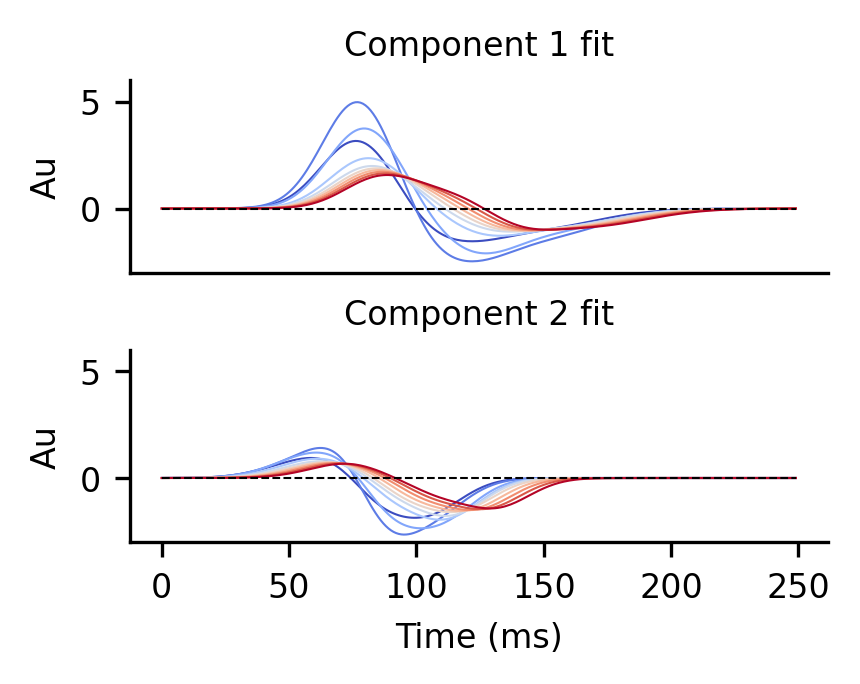

In [14]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(2, figsize = (3,2))

ax[0].plot(predictions[best][0].numpy().T, linewidth = linewidth)
ax[0].set_title("Component 1 fit", fontsize = fontsize)
ax[0].set_xticks([])

ax[1].plot(predictions[best][1].numpy().T, linewidth = linewidth)
ax[1].set_title('Component 2 fit', fontsize = fontsize)
for i in range(2):
    ax[i].set_ylabel("Au", fontsize = fontsize)
    ax[i].plot(np.zeros(250), '--', color = 'black', linewidth = linewidth)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    
ax[0].set_ylim(-3,6)
ax[1].set_ylim(-3,6)
ax[1].set_xlabel("Time (ms)", fontsize = fontsize)
fig.subplots_adjust(hspace=0.4)

# figname = 'model_predicted_component_response_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [15]:
# for i in range(100):
#     cmap = plt.get_cmap('coolwarm') 
#     rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
#     fig, ax = plt.subplots(1,5, figsize = (8,1.5))

#     ax[0].plot(model.dlgn_exc[i][0,0].numpy().T, linewidth = linewidth)
#     ax[1].plot(model.dlgn_exc[i][0,1].numpy().T, linewidth = linewidth)
#     ax[2].plot(model.dlgn_exc[i][0,2].numpy().T, linewidth = linewidth)
#     ax[3].plot(model.v1_exc[i][0].numpy().T, linewidth = linewidth)
#     ax[4].plot(predictions[i][0].numpy().T, linewidth = linewidth)

#     for i in range(5):
#         if i>0:
#             ax[i].set_yticks([])
#         ax[i].spines['top'].set_visible(False)
#         ax[i].spines['right'].set_visible(False)
#         ax[i].tick_params(labelsize = fontsize)
#         ax[i].set_ylim(-3,6.5)
#         ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

#     fig.subplots_adjust(wspace=0.05)
#     ax[0].set_ylabel("Firing rate", fontsize = fontsize)

#     ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
#     ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
#     ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
#     ax[3].set_title("Sum", fontsize = fontsize)
#     ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

#     plt.suptitle("V1 Neuron 1 (High latency unit)", y = 1.15, fontsize = fontsize)

#     cmap = plt.get_cmap('coolwarm') 
#     rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
#     fig, ax = plt.subplots(1,5, figsize = (8,1.5))

#     ax[0].plot(model.dlgn_exc[i][1,0].numpy().T, linewidth = linewidth)
#     ax[1].plot(model.dlgn_exc[i][1,1].numpy().T, linewidth = linewidth)
#     ax[2].plot(model.dlgn_exc[i][1,2].numpy().T, linewidth = linewidth)
#     ax[3].plot(model.v1_exc[i][1].numpy().T, linewidth = linewidth)
#     ax[4].plot(predictions[i][1].numpy().T, linewidth = linewidth)

#     for i in range(5):
#         if i>0:
#             ax[i].set_yticks([])
#         ax[i].spines['top'].set_visible(False)
#         ax[i].spines['right'].set_visible(False)
#         ax[i].tick_params(labelsize = fontsize)
#         ax[i].set_ylim(-3,6.5)
#         ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

#     fig.subplots_adjust(wspace=0.05)
#     ax[0].set_ylabel("Firing rate", fontsize = fontsize)

#     ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
#     ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
#     ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
#     ax[3].set_title("Sum", fontsize = fontsize)
#     ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

#     plt.suptitle("V1 Neuron 2 (Low latency unit)", y = 1.15, fontsize = fontsize)

Text(0.5, 1.15, 'V1 Neuron 1 (High latency unit)')

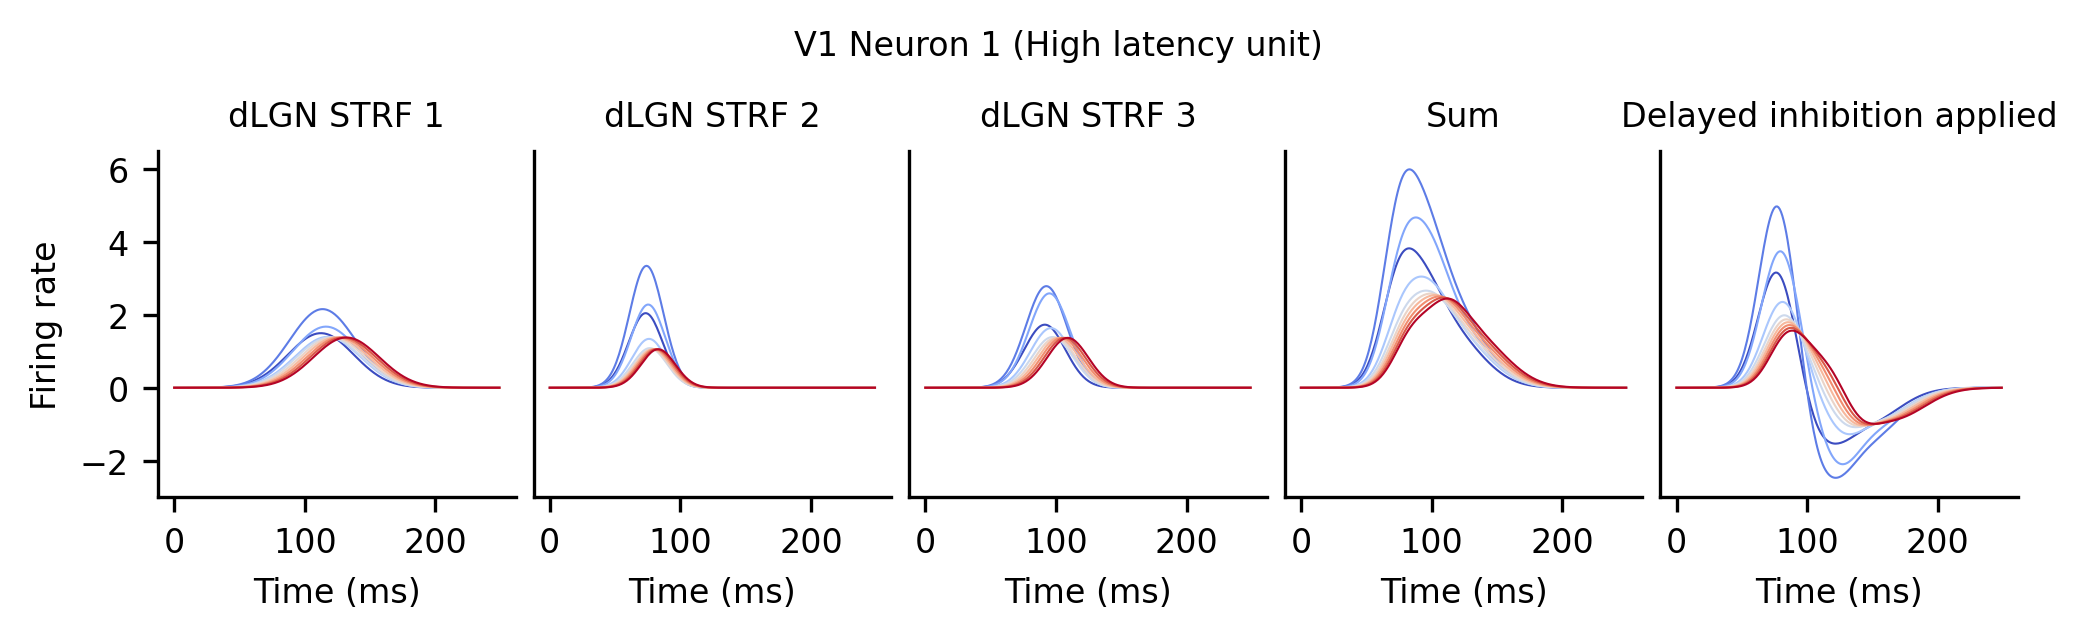

In [16]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(1,5, figsize = (8,1.5))

ax[0].plot(model.dlgn_exc[best][0,0].numpy().T, linewidth = linewidth)
ax[1].plot(model.dlgn_exc[best][0,1].numpy().T, linewidth = linewidth)
ax[2].plot(model.dlgn_exc[best][0,2].numpy().T, linewidth = linewidth)
ax[3].plot(model.v1_exc[best][0].numpy().T, linewidth = linewidth)
ax[4].plot(predictions[best][0].numpy().T, linewidth = linewidth)

for i in range(5):
    if i>0:
        ax[i].set_yticks([])
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].set_ylim(-3,6.5)
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(wspace=0.05)
ax[0].set_ylabel("Firing rate", fontsize = fontsize)

ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
ax[3].set_title("Sum", fontsize = fontsize)
ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

plt.suptitle("V1 Neuron 1 (High latency unit)", y = 1.15, fontsize = fontsize)

# figname = 'model_predicted_construction_response1_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.5, 1.15, 'V1 Neuron 2 (Low latency unit)')

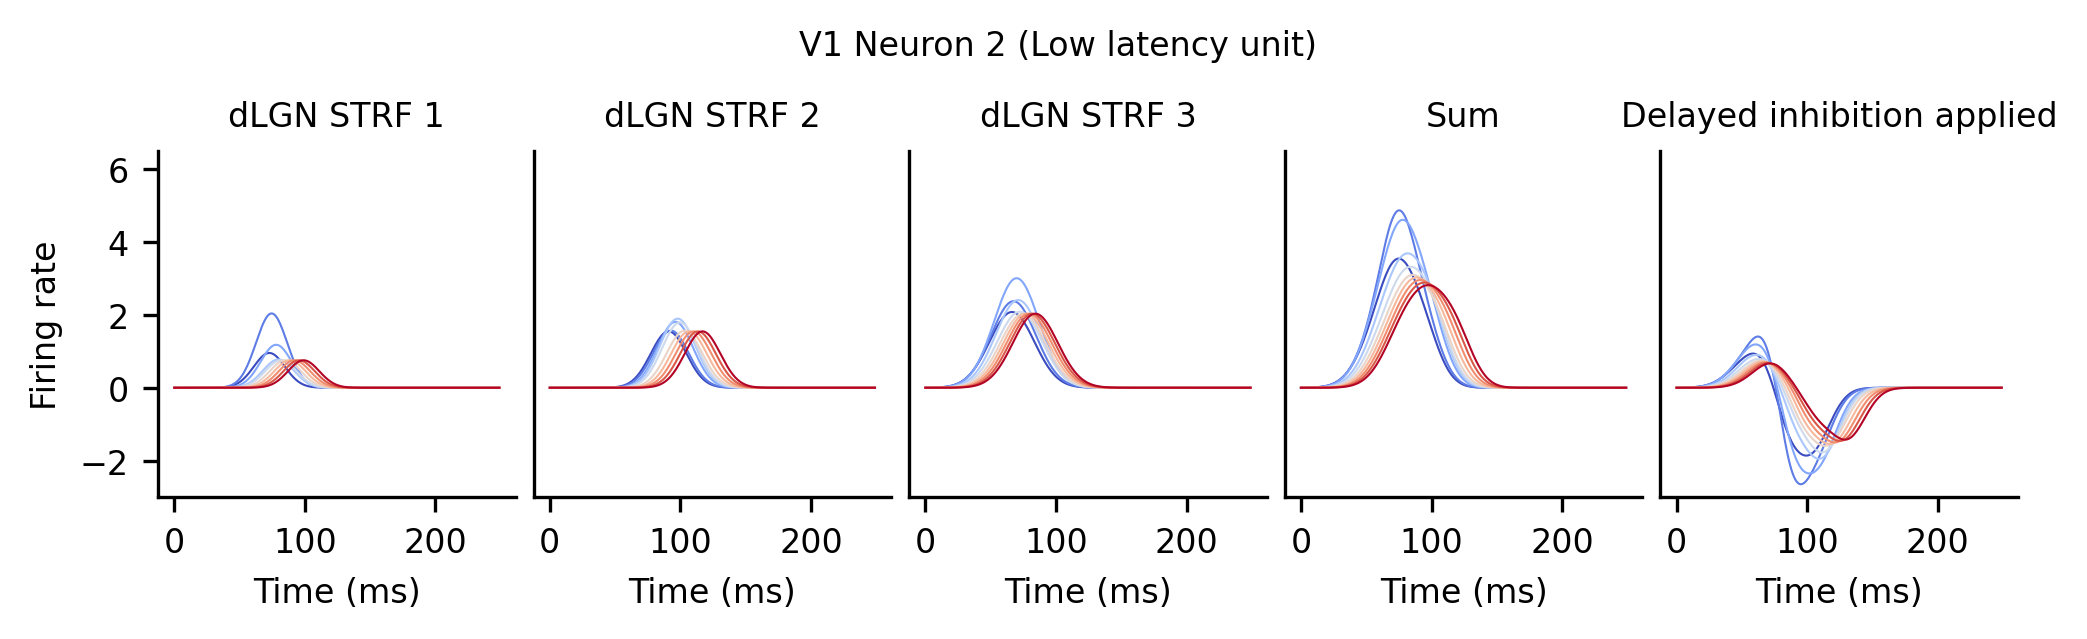

In [17]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(1,5, figsize = (8,1.5))

ax[0].plot(model.dlgn_exc[best][1,0].numpy().T, linewidth = linewidth)
ax[1].plot(model.dlgn_exc[best][1,1].numpy().T, linewidth = linewidth)
ax[2].plot(model.dlgn_exc[best][1,2].numpy().T, linewidth = linewidth)
ax[3].plot(model.v1_exc[best][1].numpy().T, linewidth = linewidth)
ax[4].plot(predictions[best][1].numpy().T, linewidth = linewidth)

for i in range(5):
    if i>0:
        ax[i].set_yticks([])
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].set_ylim(-3,6.5)
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(wspace=0.05)
ax[0].set_ylabel("Firing rate", fontsize = fontsize)

ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
ax[3].set_title("Sum", fontsize = fontsize)
ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

plt.suptitle("V1 Neuron 2 (Low latency unit)", y = 1.15, fontsize = fontsize)

# figname = 'model_predicted_construction_response2_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.5, 1.1, 'V1 Neuron 1')

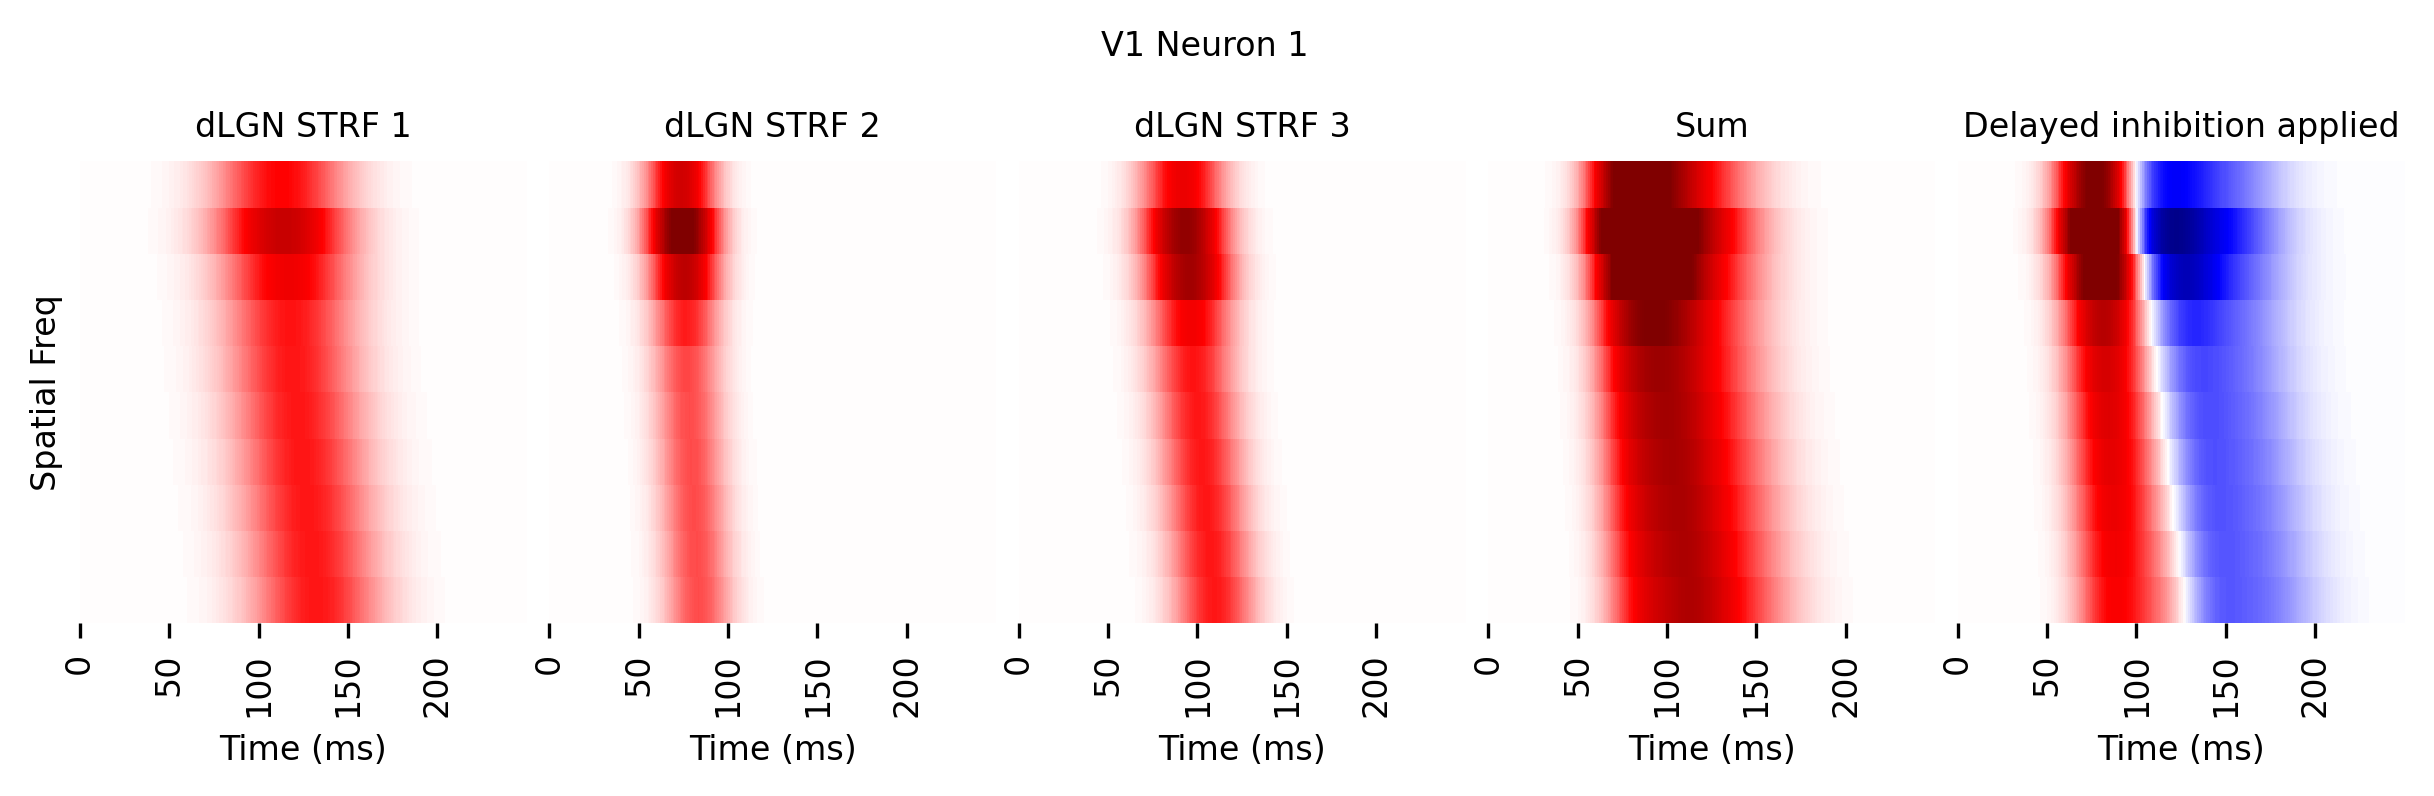

In [18]:
fig, ax = plt.subplots(1,5, figsize = (10,2))

sns.heatmap(model.dlgn_exc[best][0,0], ax = ax[0], cbar = False, cmap = 'seismic', vmin = -3, vmax = 3)
sns.heatmap(model.dlgn_exc[best][0,1], ax = ax[1], cbar = False, cmap = 'seismic', vmin = -3, vmax = 3)
sns.heatmap(model.dlgn_exc[best][0,2], ax = ax[2], cbar = False, cmap = 'seismic', vmin = -3, vmax = 3)
sns.heatmap(model.v1_exc[best][0], ax = ax[3], cbar = False, cmap = 'seismic', vmin = -3, vmax = 3)
sns.heatmap(predictions[best][0], ax = ax[4], cbar = False, cmap = 'seismic', vmin = -3, vmax = 3)

for i in range(5):
    ax[i].set_yticks([])
    ax[i].tick_params(labelsize = fontsize)
    ax[i].set_xticks(np.arange(0,250,50))
    ax[i].set_xticklabels(np.arange(0,250,50), fontsize = fontsize)
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(wspace=0.05)
ax[0].set_ylabel("Spatial Freq", fontsize = fontsize)

ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
ax[3].set_title("Sum", fontsize = fontsize)
ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

plt.suptitle("V1 Neuron 1", y = 1.1, fontsize = fontsize)

# figname = 'model_predicted_construction_response1_heatmap_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.5, 1.1, 'V1 Neuron 2')

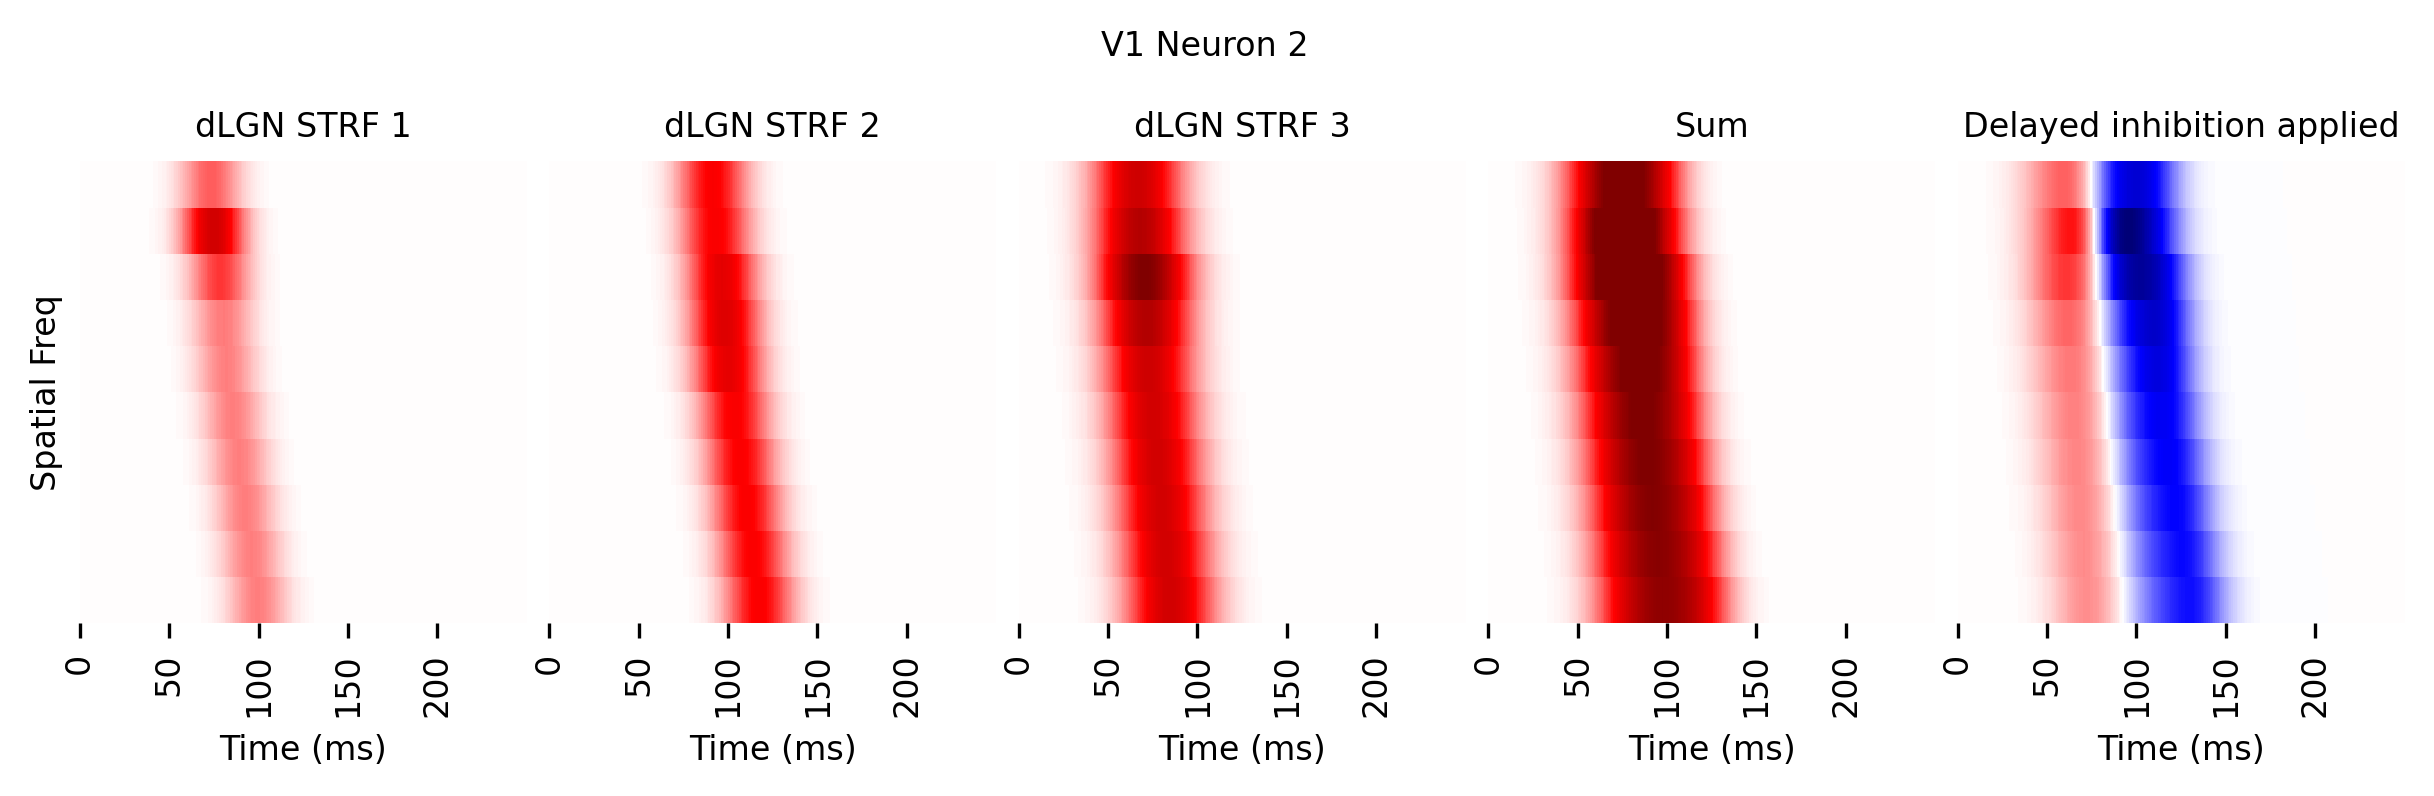

In [19]:
fig, ax = plt.subplots(1,5, figsize = (10,2))

sns.heatmap(model.dlgn_exc[best][1,0], ax = ax[0], cbar = False, cmap = 'seismic', vmin = -3, vmax = 3)
sns.heatmap(model.dlgn_exc[best][1,1], ax = ax[1], cbar = False, cmap = 'seismic', vmin = -3, vmax = 3)
sns.heatmap(model.dlgn_exc[best][1,2], ax = ax[2], cbar = False, cmap = 'seismic', vmin = -3, vmax = 3)
sns.heatmap(model.v1_exc[best][1], ax = ax[3], cbar = False, cmap = 'seismic', vmin = -3, vmax = 3)
sns.heatmap(predictions[best][1], ax = ax[4], cbar = False, cmap = 'seismic', vmin = -3, vmax = 3)

for i in range(5):
    ax[i].set_yticks([])
    ax[i].tick_params(labelsize = fontsize)
    ax[i].set_xticks(np.arange(0,250,50))
    ax[i].set_xticklabels(np.arange(0,250,50), fontsize = fontsize)
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(wspace=0.05)
ax[0].set_ylabel("Spatial Freq", fontsize = fontsize)

ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
ax[3].set_title("Sum", fontsize = fontsize)
ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

plt.suptitle("V1 Neuron 2", y = 1.1, fontsize = fontsize)

# figname = 'model_predicted_construction_response2_heatmap_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [20]:
x = np.arange(0.02,0.34,0.02)

In [21]:
def gaussian(
    support, # domain of the function
    ctr, # mean of the function
    mid, # midline of the function
    amp, # amplitude of the function
    std # bandwidth parameter
):

    f = np.exp(-1*(((support-ctr)**2)/(2*std**2)))

    return mid+(amp*f)

Text(0.5, 1.025, 'dLGN_1 into V1_1')

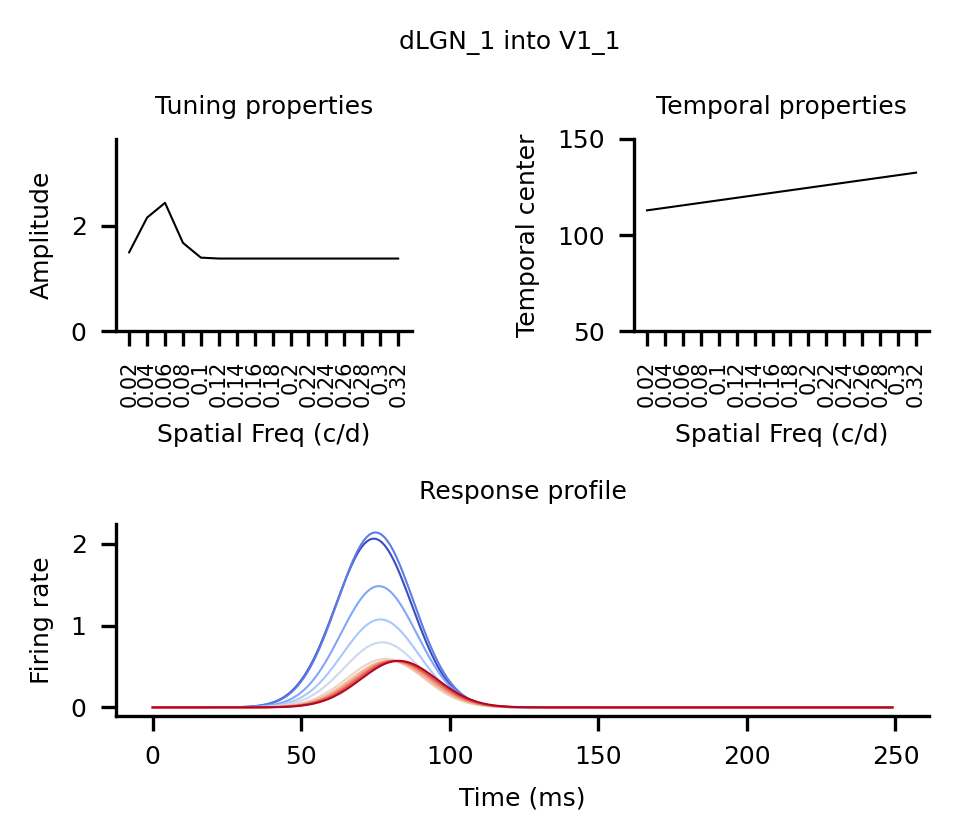

In [22]:
fig = plt.figure(figsize=(3.5, 2.5))
grid = plt.GridSpec(2, 2, hspace=1, wspace=0.75)

ax = [
    fig.add_subplot(grid[:1, 0]),
    fig.add_subplot(grid[:1,1]),
    fig.add_subplot(grid[1:,:]),
]

for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = 6)

tuning_params = model.params['dLGN_params'][best, 0, 0, 2:6, 0,0].numpy()
time_params = model.params['dLGN_params'][best, 0, 0, :2, 0,0].numpy()

tuning_curve = gaussian(x,*tuning_params)
ctf_line = x*time_params[0]+time_params[1]

ax[0].plot(tuning_curve, linewidth = linewidth, color = 'black')
ax[0].set_xticks(np.arange(16))
ax[0].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[0].set_ylim(0, tuning_curve.max()+tuning_curve.max()*0.5)

ax[1].plot(ctf_line, linewidth = linewidth, color = 'black')
ax[1].set_xticks(np.arange(16))
ax[1].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[1].set_ylim(50,150)

ax[2].plot(model.dlgn_exc[0][0,0].numpy().T, linewidth = linewidth)

ax[0].set_title("Tuning properties", fontsize = 6)
ax[0].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[0].set_ylabel("Amplitude", fontsize = 6)
ax[1].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[1].set_ylabel("Temporal center", fontsize = 6)
ax[1].set_title("Temporal properties", fontsize = 6)
ax[2].set_title("Response profile", fontsize = 6)
ax[2].set_xlabel("Time (ms)", fontsize = 6)
ax[2].set_ylabel("Firing rate", fontsize = 6)

plt.suptitle("dLGN_1 into V1_1", fontsize = 6, y = 1.025)

# figname = 'model_predicted_dlgn1_1_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.5, 1.025, 'dLGN_2 into V1_1')

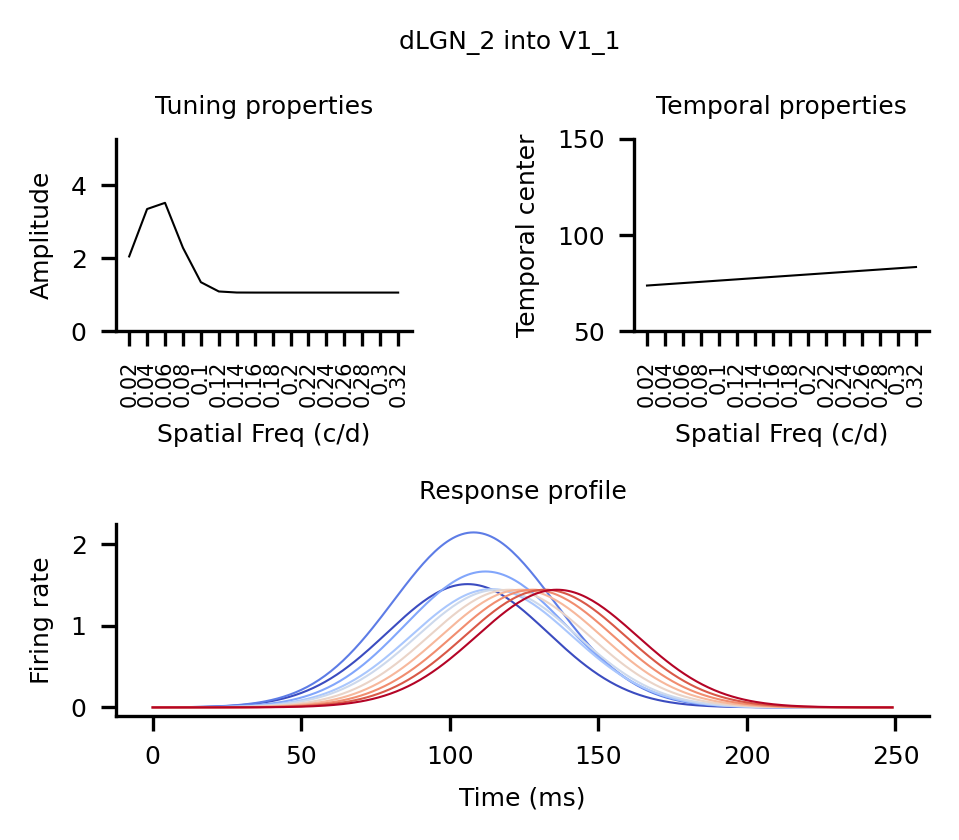

In [23]:
fig = plt.figure(figsize=(3.5, 2.5))
grid = plt.GridSpec(2, 2, hspace=1, wspace=0.75)

ax = [
    fig.add_subplot(grid[:1, 0]),
    fig.add_subplot(grid[:1,1]),
    fig.add_subplot(grid[1:,:]),
]

for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = 6)

tuning_params = model.params['dLGN_params'][best, 0, 1, 2:6, 0,0].numpy()
time_params = model.params['dLGN_params'][best, 0, 1, :2, 0,0].numpy()

tuning_curve = gaussian(x,*tuning_params)
ctf_line = x*time_params[0]+time_params[1]

ax[0].plot(tuning_curve, linewidth = linewidth, color = 'black')
ax[0].set_xticks(np.arange(16))
ax[0].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[0].set_ylim(0, tuning_curve.max()+tuning_curve.max()*0.5)

ax[1].plot(ctf_line, linewidth = linewidth, color = 'black')
ax[1].set_xticks(np.arange(16))
ax[1].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[1].set_ylim(50,150)

ax[2].plot(model.dlgn_exc[0][0,1].numpy().T, linewidth = linewidth)

ax[0].set_title("Tuning properties", fontsize = 6)
ax[0].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[0].set_ylabel("Amplitude", fontsize = 6)
ax[1].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[1].set_ylabel("Temporal center", fontsize = 6)
ax[1].set_title("Temporal properties", fontsize = 6)
ax[2].set_title("Response profile", fontsize = 6)
ax[2].set_xlabel("Time (ms)", fontsize = 6)
ax[2].set_ylabel("Firing rate", fontsize = 6)

plt.suptitle("dLGN_2 into V1_1", fontsize = 6, y = 1.025)

# figname = 'model_predicted_dlgn1_2_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)


Text(0.5, 1.025, 'dLGN_3 into V1_1')

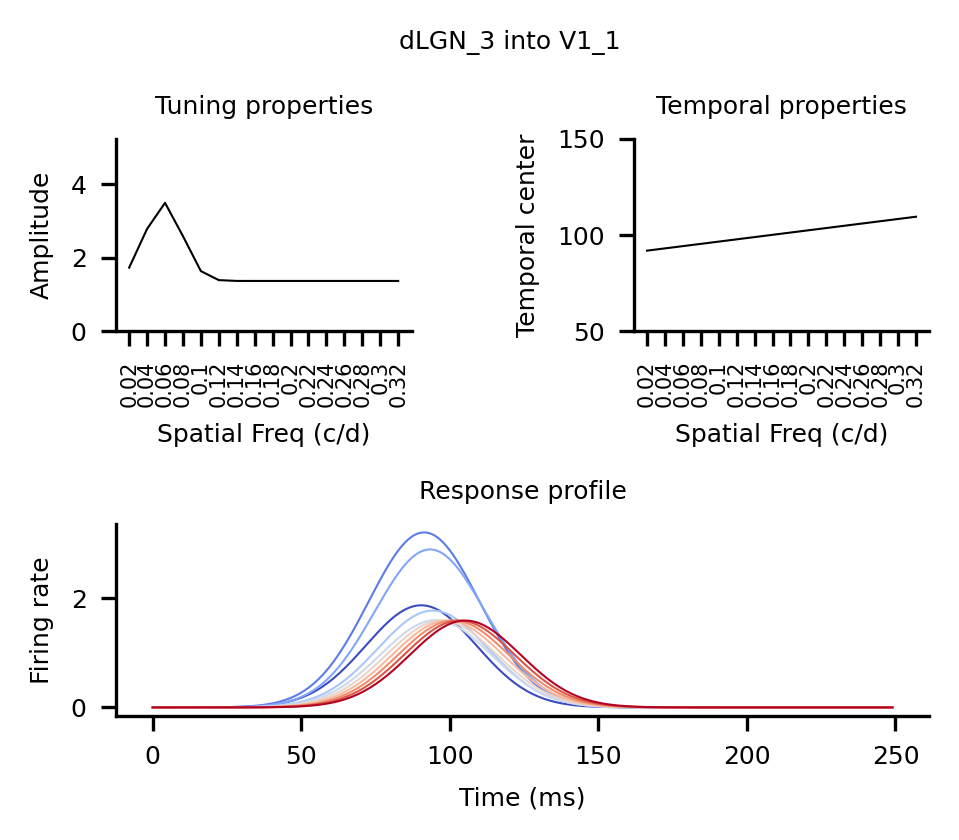

In [24]:
fig = plt.figure(figsize=(3.5, 2.5))
grid = plt.GridSpec(2, 2, hspace=1, wspace=0.75)

ax = [
    fig.add_subplot(grid[:1, 0]),
    fig.add_subplot(grid[:1,1]),
    fig.add_subplot(grid[1:,:]),
]

for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = 6)

tuning_params = model.params['dLGN_params'][best, 0, 2, 2:6, 0,0].numpy()
time_params = model.params['dLGN_params'][best, 0, 2, :2, 0,0].numpy()

tuning_curve = gaussian(x,*tuning_params)
ctf_line = x*time_params[0]+time_params[1]

ax[0].plot(tuning_curve, linewidth = linewidth, color = 'black')
ax[0].set_xticks(np.arange(16))
ax[0].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[0].set_ylim(0, tuning_curve.max()+tuning_curve.max()*0.5)

ax[1].plot(ctf_line, linewidth = linewidth, color = 'black')
ax[1].set_xticks(np.arange(16))
ax[1].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[1].set_ylim(50,150)

ax[2].plot(model.dlgn_exc[0][0,2].numpy().T, linewidth = linewidth)

ax[0].set_title("Tuning properties", fontsize = 6)
ax[0].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[0].set_ylabel("Amplitude", fontsize = 6)
ax[1].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[1].set_ylabel("Temporal center", fontsize = 6)
ax[1].set_title("Temporal properties", fontsize = 6)
ax[2].set_title("Response profile", fontsize = 6)
ax[2].set_xlabel("Time (ms)", fontsize = 6)
ax[2].set_ylabel("Firing rate", fontsize = 6)

plt.suptitle("dLGN_3 into V1_1", fontsize = 6, y = 1.025)

# figname = 'model_predicted_dlgn1_3_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.5, 1.025, 'dLGN_1 into V1_2')

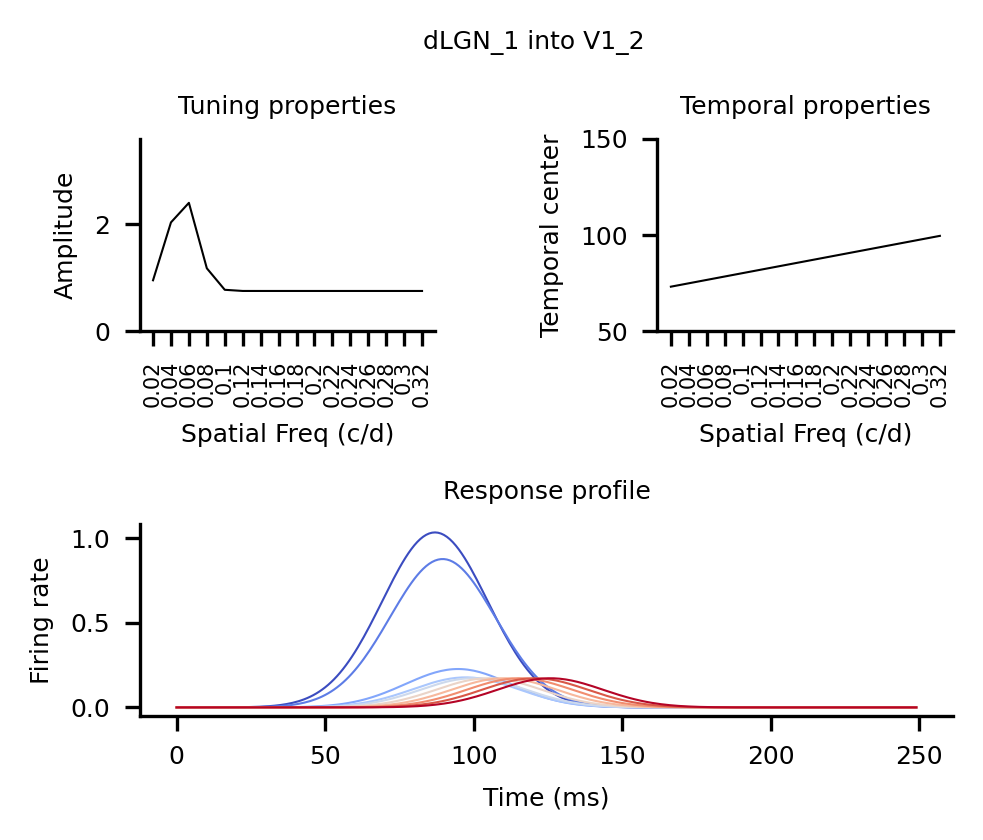

In [25]:
fig = plt.figure(figsize=(3.5, 2.5))
grid = plt.GridSpec(2, 2, hspace=1, wspace=0.75)

ax = [
    fig.add_subplot(grid[:1, 0]),
    fig.add_subplot(grid[:1,1]),
    fig.add_subplot(grid[1:,:]),
]

for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = 6)

tuning_params = model.params['dLGN_params'][best, 1, 0, 2:6, 0,0].numpy()
time_params = model.params['dLGN_params'][best, 1, 0, :2, 0,0].numpy()

tuning_curve = gaussian(x,*tuning_params)
ctf_line = x*time_params[0]+time_params[1]

ax[0].plot(tuning_curve, linewidth = linewidth, color = 'black')
ax[0].set_xticks(np.arange(16))
ax[0].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[0].set_ylim(0, tuning_curve.max()+tuning_curve.max()*0.5)

ax[1].plot(ctf_line, linewidth = linewidth, color = 'black')
ax[1].set_xticks(np.arange(16))
ax[1].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[1].set_ylim(50,150)

ax[2].plot(model.dlgn_exc[0][1,0].numpy().T, linewidth = linewidth)

ax[0].set_title("Tuning properties", fontsize = 6)
ax[0].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[0].set_ylabel("Amplitude", fontsize = 6)
ax[1].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[1].set_ylabel("Temporal center", fontsize = 6)
ax[1].set_title("Temporal properties", fontsize = 6)
ax[2].set_title("Response profile", fontsize = 6)
ax[2].set_xlabel("Time (ms)", fontsize = 6)
ax[2].set_ylabel("Firing rate", fontsize = 6)

plt.suptitle("dLGN_1 into V1_2", fontsize = 6, y = 1.025)

# figname = 'model_predicted_dlgn2_1_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)


Text(0.5, 1.025, 'dLGN_2 into V1_2')

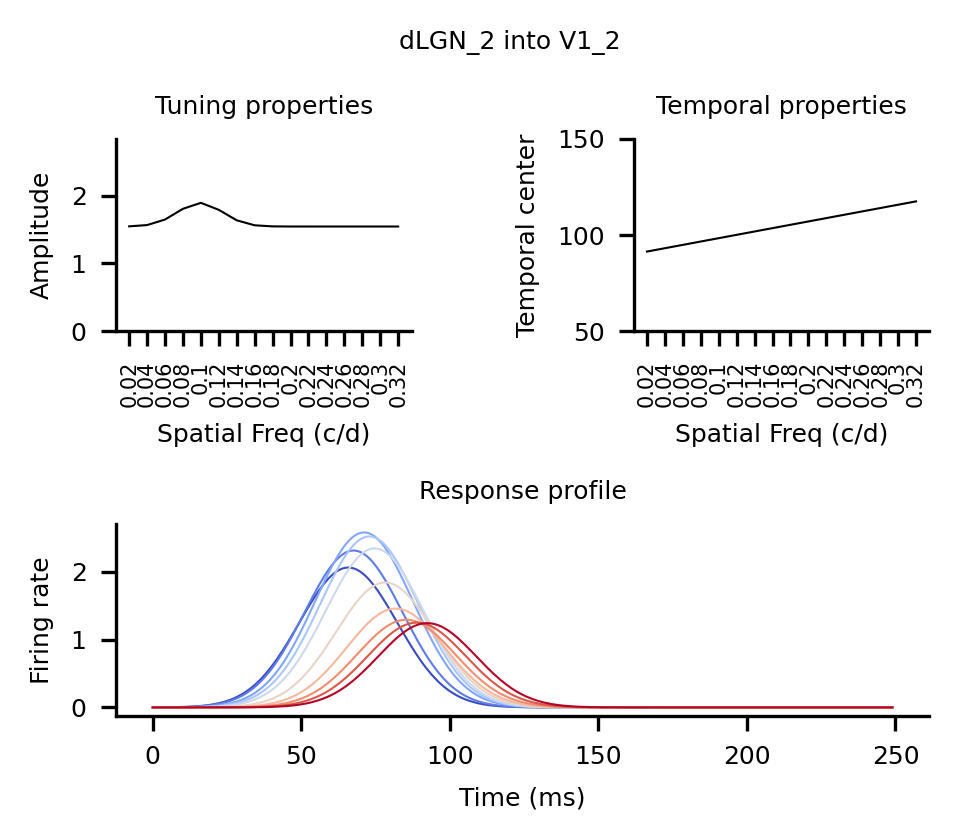

In [26]:
fig = plt.figure(figsize=(3.5, 2.5))
grid = plt.GridSpec(2, 2, hspace=1, wspace=0.75)

ax = [
    fig.add_subplot(grid[:1, 0]),
    fig.add_subplot(grid[:1,1]),
    fig.add_subplot(grid[1:,:]),
]

for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = 6)

tuning_params = model.params['dLGN_params'][best, 1, 1, 2:6, 0,0].numpy()
time_params = model.params['dLGN_params'][best, 1, 1, :2, 0,0].numpy()

tuning_curve = gaussian(x,*tuning_params)
ctf_line = x*time_params[0]+time_params[1]

ax[0].plot(tuning_curve, linewidth = linewidth, color = 'black')
ax[0].set_xticks(np.arange(16))
ax[0].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[0].set_ylim(0, tuning_curve.max()+tuning_curve.max()*0.5)

ax[1].plot(ctf_line, linewidth = linewidth, color = 'black')
ax[1].set_xticks(np.arange(16))
ax[1].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[1].set_ylim(50,150)

ax[2].plot(model.dlgn_exc[0][1,1].numpy().T, linewidth = linewidth)

ax[0].set_title("Tuning properties", fontsize = 6)
ax[0].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[0].set_ylabel("Amplitude", fontsize = 6)
ax[1].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[1].set_ylabel("Temporal center", fontsize = 6)
ax[1].set_title("Temporal properties", fontsize = 6)
ax[2].set_title("Response profile", fontsize = 6)
ax[2].set_xlabel("Time (ms)", fontsize = 6)
ax[2].set_ylabel("Firing rate", fontsize = 6)

plt.suptitle("dLGN_2 into V1_2", fontsize = 6, y = 1.025)

# figname = 'model_predicted_dlgn2_2_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)


Text(0.5, 1.025, 'dLGN_3 into V1_2')

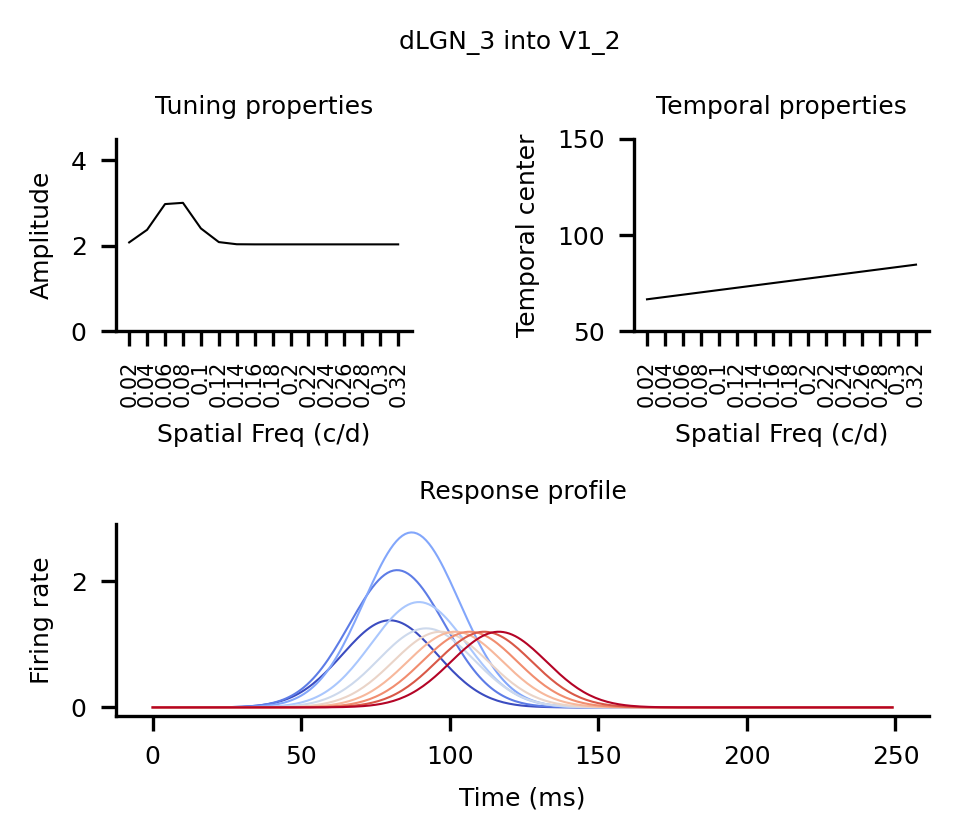

In [27]:
fig = plt.figure(figsize=(3.5, 2.5))
grid = plt.GridSpec(2, 2, hspace=1, wspace=0.75)

ax = [
    fig.add_subplot(grid[:1, 0]),
    fig.add_subplot(grid[:1,1]),
    fig.add_subplot(grid[1:,:]),
]

for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = 6)

tuning_params = model.params['dLGN_params'][best, 1, 2, 2:6, 0,0].numpy()
time_params = model.params['dLGN_params'][best, 1, 2, :2, 0,0].numpy()

tuning_curve = gaussian(x,*tuning_params)
ctf_line = x*time_params[0]+time_params[1]

ax[0].plot(tuning_curve, linewidth = linewidth, color = 'black')
ax[0].set_xticks(np.arange(16))
ax[0].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[0].set_ylim(0, tuning_curve.max()+tuning_curve.max()*0.5)

ax[1].plot(ctf_line, linewidth = linewidth, color = 'black')
ax[1].set_xticks(np.arange(16))
ax[1].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[1].set_ylim(50,150)

ax[2].plot(model.dlgn_exc[0][1,2].numpy().T, linewidth = linewidth)

ax[0].set_title("Tuning properties", fontsize = 6)
ax[0].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[0].set_ylabel("Amplitude", fontsize = 6)
ax[1].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[1].set_ylabel("Temporal center", fontsize = 6)
ax[1].set_title("Temporal properties", fontsize = 6)
ax[2].set_title("Response profile", fontsize = 6)
ax[2].set_xlabel("Time (ms)", fontsize = 6)
ax[2].set_ylabel("Firing rate", fontsize = 6)

plt.suptitle("dLGN_3 into V1_2", fontsize = 6, y = 1.025)

# figname = 'model_predicted_dlgn2_3_best_free.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)
